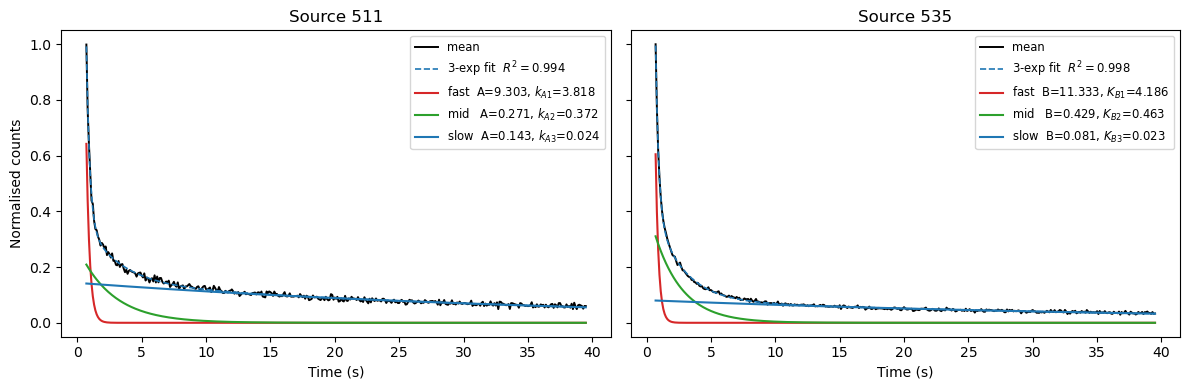

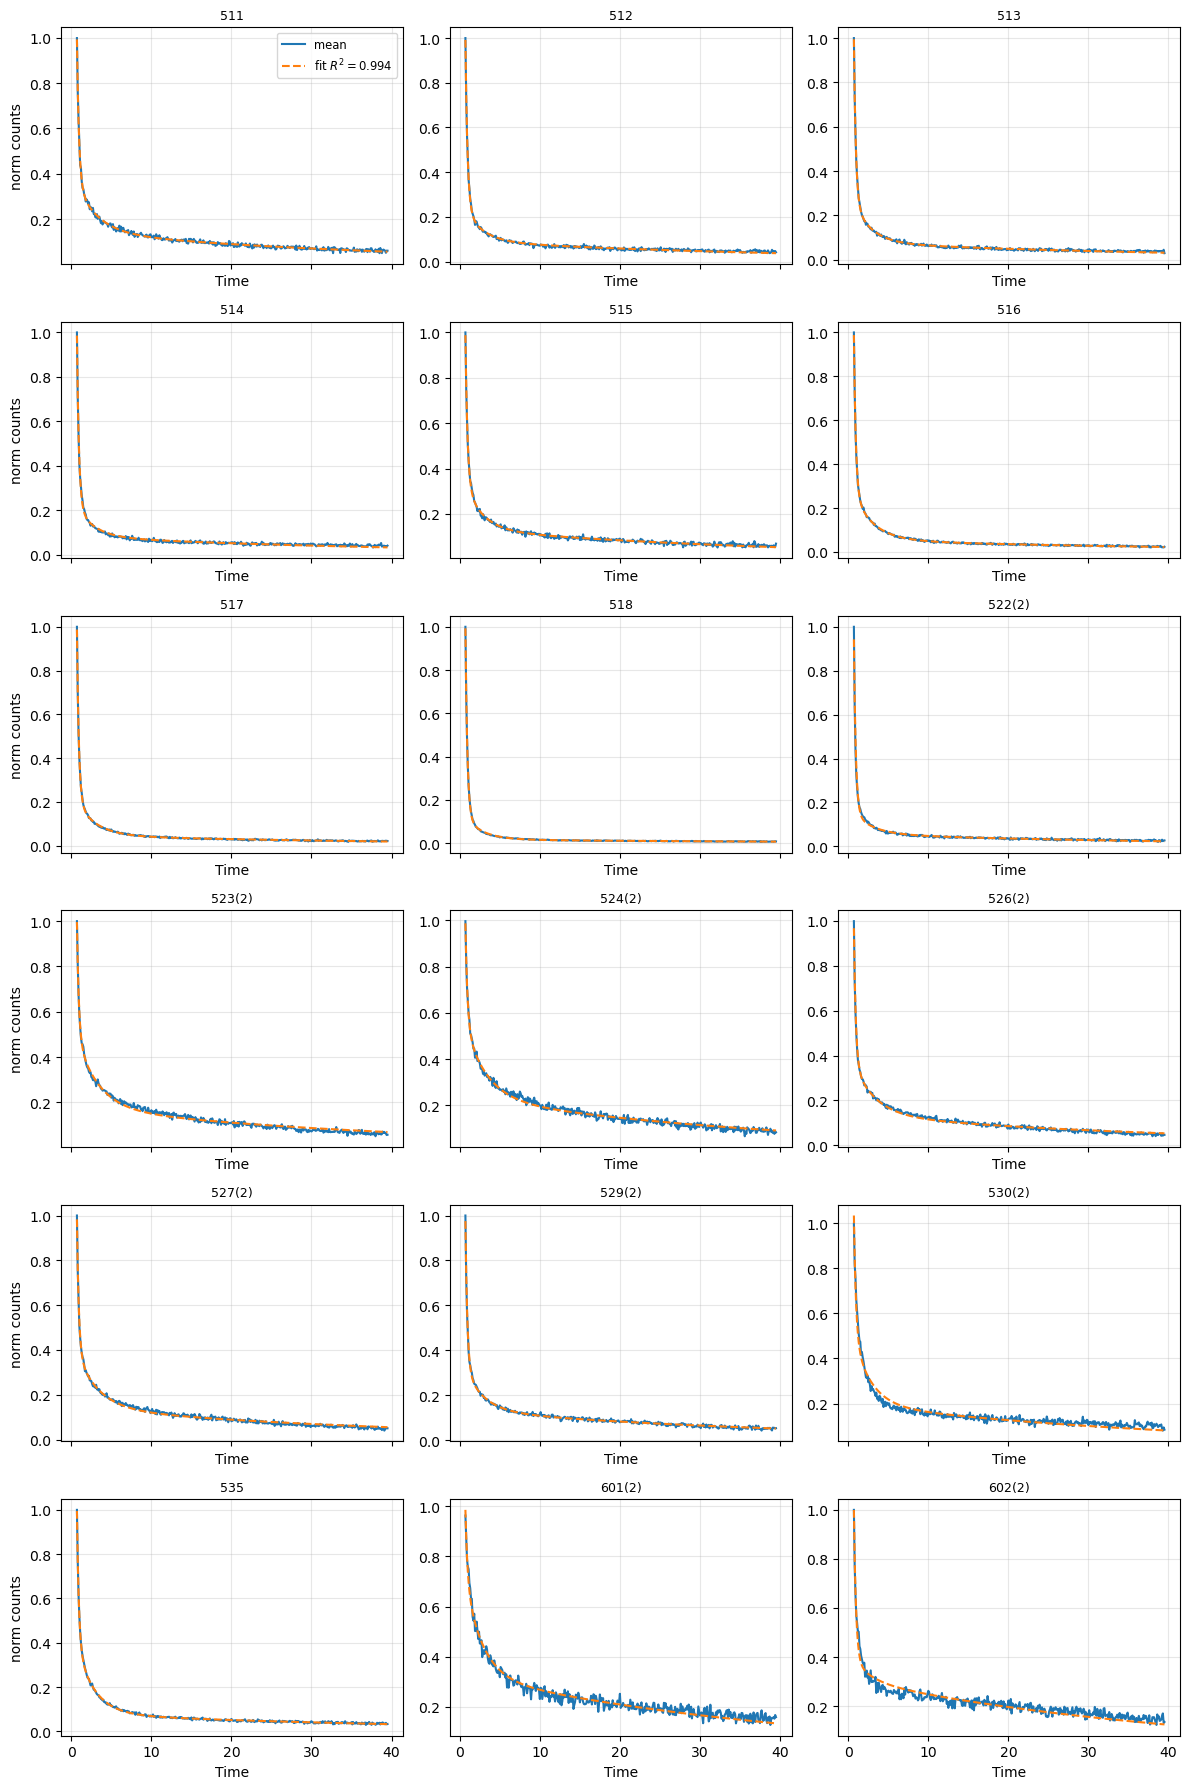


=== Six‑exp amplitudes & total‑signal mixing fractions ===
        A1′(511)  A2′(511)  A3′(511)  B1′(535)  B2′(535)  B3′(535)      R²  Frac_511_total  Frac_535_total
Sample                                                                                                    
511       8.4263    0.2543    0.1436    1.0949    0.0215    0.0000  0.9939          0.8877          0.1123
512       9.8120    0.0000    0.0000    1.4498    0.2019    0.0921  0.9947          0.8491          0.1509
513       2.4592    0.0000    0.0000   10.5893    0.2528    0.0779  0.9967          0.1838          0.8162
514       4.4838    0.0000    0.0000    8.5674    0.1908    0.0822  0.9937          0.3365          0.6635
515       8.9077    0.0000    0.0000    0.8038    0.2756    0.1325  0.9937          0.8802          0.1198
516       0.0000    0.1361    0.0000   13.4661    0.1512    0.0556  0.9987          0.0099          0.9901
517       0.0000    0.0818    0.0000   14.6694    0.1309    0.0472  0.9989          

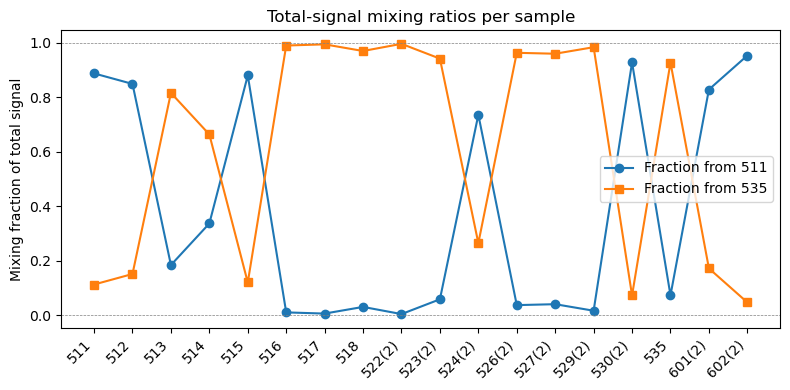

In [25]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from   scipy.optimize import curve_fit, nnls

# ╭──────────────────────────────────────────────────────────╮
# │ 0.  ── CHOOSE THE TWO SOURCE SAMPLES HERE  ──────────────│
# ╰──────────────────────────────────────────────────────────╯
# SOURCE_A = "601(2)"          # ← change to whatever sample you like
# SOURCE_B = "602(2)"          # ← change to another sample key


SOURCE_A = "511"          # ← change to whatever sample you like
SOURCE_B = "535"          # ← change to another sample key

# SOURCE_A = "511"          # ← change to whatever sample you like
# SOURCE_B = "602(2)"          # ← change to another sample key


# (everything below adapts automatically)

# ╭──────────────────────────────────────────────────────────╮
# │ 1.  Helper utilities                                     │
# ╰──────────────────────────────────────────────────────────╯
def load_data(path="output/processed_new_data_ori.pkl"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Pickle not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)

def slice_columns(df, key):
    prefix = f"Sample_{key.split('(')[0]}"
    return [c for c in df.columns if c.startswith(prefix)]

def minmax_scale_df(df, key):
    for col in slice_columns(df, key):
        vmin, vmax = df[col].min(), df[col].max()
        df[col] = (df[col] - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return df

def mean_curve(df, key):
    t = df["Time"].values.astype(float)
    y = df[slice_columns(df, key)].mean(axis=1).values.astype(float)
    return t, y

def triple_exp(t, A1, k1, A2, k2, A3, k3):
    return A1*np.exp(-k1*t) + A2*np.exp(-k2*t) + A3*np.exp(-k3*t)

def r2_score(y_true, y_pred):
    sst = np.sum((y_true - np.mean(y_true))**2)
    sse = np.sum((y_true - y_pred) **2)
    return 1.0 - sse/sst

def sort_amp_rate(A_vec, k_vec):
    """Return amplitudes & rates sorted fastest→slowest (desc k)."""
    order = np.argsort(-k_vec)
    return A_vec[order], k_vec[order]

# ╭──────────────────────────────────────────────────────────╮
# │ 2.  Load, cleanse, scale                                 │
# ╰──────────────────────────────────────────────────────────╯
data_dict = load_data()

# # example: drop bad slices that you know only exist for SOURCE_A
# bad_cols = ["Sample_601(1)","Sample_601(4)","Sample_601(8)",
#             "Sample_601(12)","Sample_601(19)","Sample_601(24)"]
# if SOURCE_A in data_dict:
#     data_dict[SOURCE_A].drop(columns=bad_cols, errors="ignore", inplace=True)

for key in data_dict:
    data_dict[key] = minmax_scale_df(data_dict[key], key)

# ╭──────────────────────────────────────────────────────────╮
# │ 3.  Fit the two source samples with a 3‑exponential model│
# ╰──────────────────────────────────────────────────────────╯
# ---- SOURCE_A ----
tA, yA = mean_curve(data_dict[SOURCE_A], SOURCE_A)
p0_A = [0.8, 0.01, 0.15, 0.1, 0.05, 1.0]
A1,k1,A2,k2,A3,k3 = curve_fit(triple_exp, tA, yA, p0=p0_A,
                              bounds=(0, np.inf))[0]
fitA = triple_exp(tA, A1,k1,A2,k2,A3,k3)
r2_A = r2_score(yA, fitA)

# ---- SOURCE_B ----
tB, yB = mean_curve(data_dict[SOURCE_B], SOURCE_B)
p0_B = [A1,k1,A2,k2,A3,k3]
B1,k1b,B2,k2b,B3,k3b = curve_fit(triple_exp, tB, yB, p0=p0_B,
                                 bounds=(0, np.inf))[0]
fitB = triple_exp(tB, B1,k1b,B2,k2b,B3,k3b)
r2_B = r2_score(yB, fitB)

# ╭──────────────────────────────────────────────────────────╮
# │ 4.  Figure – source fits & components                    │
# ╰──────────────────────────────────────────────────────────╯
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ---------- SOURCE_A ----------
A_sorted, kA_sorted = sort_amp_rate(np.array([A1,A2,A3]),
                                   np.array([k1,k2,k3]))
f_fastA = A_sorted[0]*np.exp(-kA_sorted[0]*tA)
f_midA  = A_sorted[1]*np.exp(-kA_sorted[1]*tA)
f_slowA = A_sorted[2]*np.exp(-kA_sorted[2]*tA)

ax = axes[0]
ax.plot(tA, yA, 'k', lw=1.4, label="mean")
ax.plot(tA, fitA, '--', lw=1.2, label=f"3‑exp fit  $R^2={r2_A:.3f}$")
ax.plot(tA, f_fastA, color='tab:red',   label=f"fast  A={A_sorted[0]:.3f}, $k_{{A1}}$={kA_sorted[0]:.3f}")
ax.plot(tA, f_midA,  color='tab:green', label=f"mid   A={A_sorted[1]:.3f}, $k_{{A2}}$={kA_sorted[1]:.3f}")
ax.plot(tA, f_slowA, color='tab:blue',  label=f"slow  A={A_sorted[2]:.3f}, $k_{{A3}}$={kA_sorted[2]:.3f}")
ax.set_title(f"Source {SOURCE_A}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalised counts")
ax.legend(fontsize="small")

# ---------- SOURCE_B ----------
B_sorted, kB_sorted = sort_amp_rate(np.array([B1,B2,B3]),
                                   np.array([k1b,k2b,k3b]))
g_fastB = B_sorted[0]*np.exp(-kB_sorted[0]*tB)
g_midB  = B_sorted[1]*np.exp(-kB_sorted[1]*tB)
g_slowB = B_sorted[2]*np.exp(-kB_sorted[2]*tB)

ax = axes[1]
ax.plot(tB, yB, 'k', lw=1.4, label="mean")
ax.plot(tB, fitB, '--', lw=1.2, label=f"3‑exp fit  $R^2={r2_B:.3f}$")
ax.plot(tB, g_fastB, color='tab:red',   label=f"fast  B={B_sorted[0]:.3f}, $K_{{B1}}$={kB_sorted[0]:.3f}")
ax.plot(tB, g_midB,  color='tab:green', label=f"mid   B={B_sorted[1]:.3f}, $K_{{B2}}$={kB_sorted[1]:.3f}")
ax.plot(tB, g_slowB, color='tab:blue',  label=f"slow  B={B_sorted[2]:.3f}, $K_{{B3}}$={kB_sorted[2]:.3f}")
ax.set_title(f"Source {SOURCE_B}")
ax.set_xlabel("Time (s)")
ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

# ╭──────────────────────────────────────────────────────────╮
# │ 5.  Six‑component NNLS fit for every sample              │
# ╰──────────────────────────────────────────────────────────╯
# reorder rates fast→mid→slow
kA_fast, kA_mid, kA_slow = kA_sorted
kB_fast, kB_mid, kB_slow = kB_sorted

def basis_matrix6(t):
    return np.column_stack([
        np.exp(-kA_fast*t), np.exp(-kA_mid*t), np.exp(-kA_slow*t),
        np.exp(-kB_fast*t), np.exp(-kB_mid*t), np.exp(-kB_slow*t)
    ])

records = []
samples = sorted(data_dict.keys())
ncols, nrows = 3, int(np.ceil(len(samples)/3))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows),
                         sharex=True, sharey=False)
axes = axes.ravel()

for idx, smp in enumerate(samples):
    t, y = mean_curve(data_dict[smp], smp)
    X    = basis_matrix6(t)
    amps, _ = nnls(X, y)
    A1p,A2p,A3p,B1p,B2p,B3p = amps
    yhat  = X @ amps
    r2    = r2_score(y, yhat)

    totA, totB = A1p+A2p+A3p, B1p+B2p+B3p
    fracA = totA/(totA+totB) if (totA+totB) else np.nan
    fracB = 1 - fracA if (totA+totB) else np.nan

    records.append([smp,*amps,r2,fracA,fracB])

    ax = axes[idx]
    ax.plot(t,y, label="mean")
    ax.plot(t,yhat,'--', label=f"fit $R^2={r2:.3f}$")
    ax.set_title(smp, fontsize=9)
    if idx % ncols == 0: ax.set_ylabel("norm counts")
    ax.set_xlabel("Time")
    ax.grid(alpha=.3)
    if idx==0: ax.legend(fontsize="small")

for ax in axes[len(samples):]: ax.axis("off")
plt.tight_layout(); plt.show()

# ╭──────────────────────────────────────────────────────────╮
# │ 6.  Coefficient / mixing tables & CSV                    │
# ╰──────────────────────────────────────────────────────────╯
col_names = [f"A{i}′({SOURCE_A})" for i in (1,2,3)] + \
            [f"B{i}′({SOURCE_B})" for i in (1,2,3)] + \
            ["R²",
             f"Frac_{SOURCE_A}_total", f"Frac_{SOURCE_B}_total"]

df_coef = (pd.DataFrame.from_records(records, columns=["Sample", *col_names])
             .set_index("Sample").round(4).sort_index())

print("\n=== Six‑exp amplitudes & total‑signal mixing fractions ===")
print(df_coef.to_string())

csv_name = f"output/six_exp_coefficients_and_mixing_{SOURCE_A}_{SOURCE_B}.csv"
df_coef.to_csv(csv_name)
print(f"\nSaved → {csv_name}")

# ╭──────────────────────────────────────────────────────────╮
# │ 7.  Mixing‑ratio line plot                               │
# ╰──────────────────────────────────────────────────────────╯
df_plot = df_coef.sort_index()
x = range(len(df_plot))

plt.figure(figsize=(8,4))
plt.plot(x, df_plot[f"Frac_{SOURCE_A}_total"], marker="o",
         label=f"Fraction from {SOURCE_A}")
plt.plot(x, df_plot[f"Frac_{SOURCE_B}_total"], marker="s",
         label=f"Fraction from {SOURCE_B}")
plt.axhline(0, color='gray', ls='--', lw=.5)
plt.axhline(1, color='gray', ls='--', lw=.5)
plt.xticks(x, df_plot.index, rotation=45, ha="right")
plt.ylabel("Mixing fraction of total signal")
plt.title("Total‑signal mixing ratios per sample")
plt.legend()
plt.tight_layout()
plt.show()


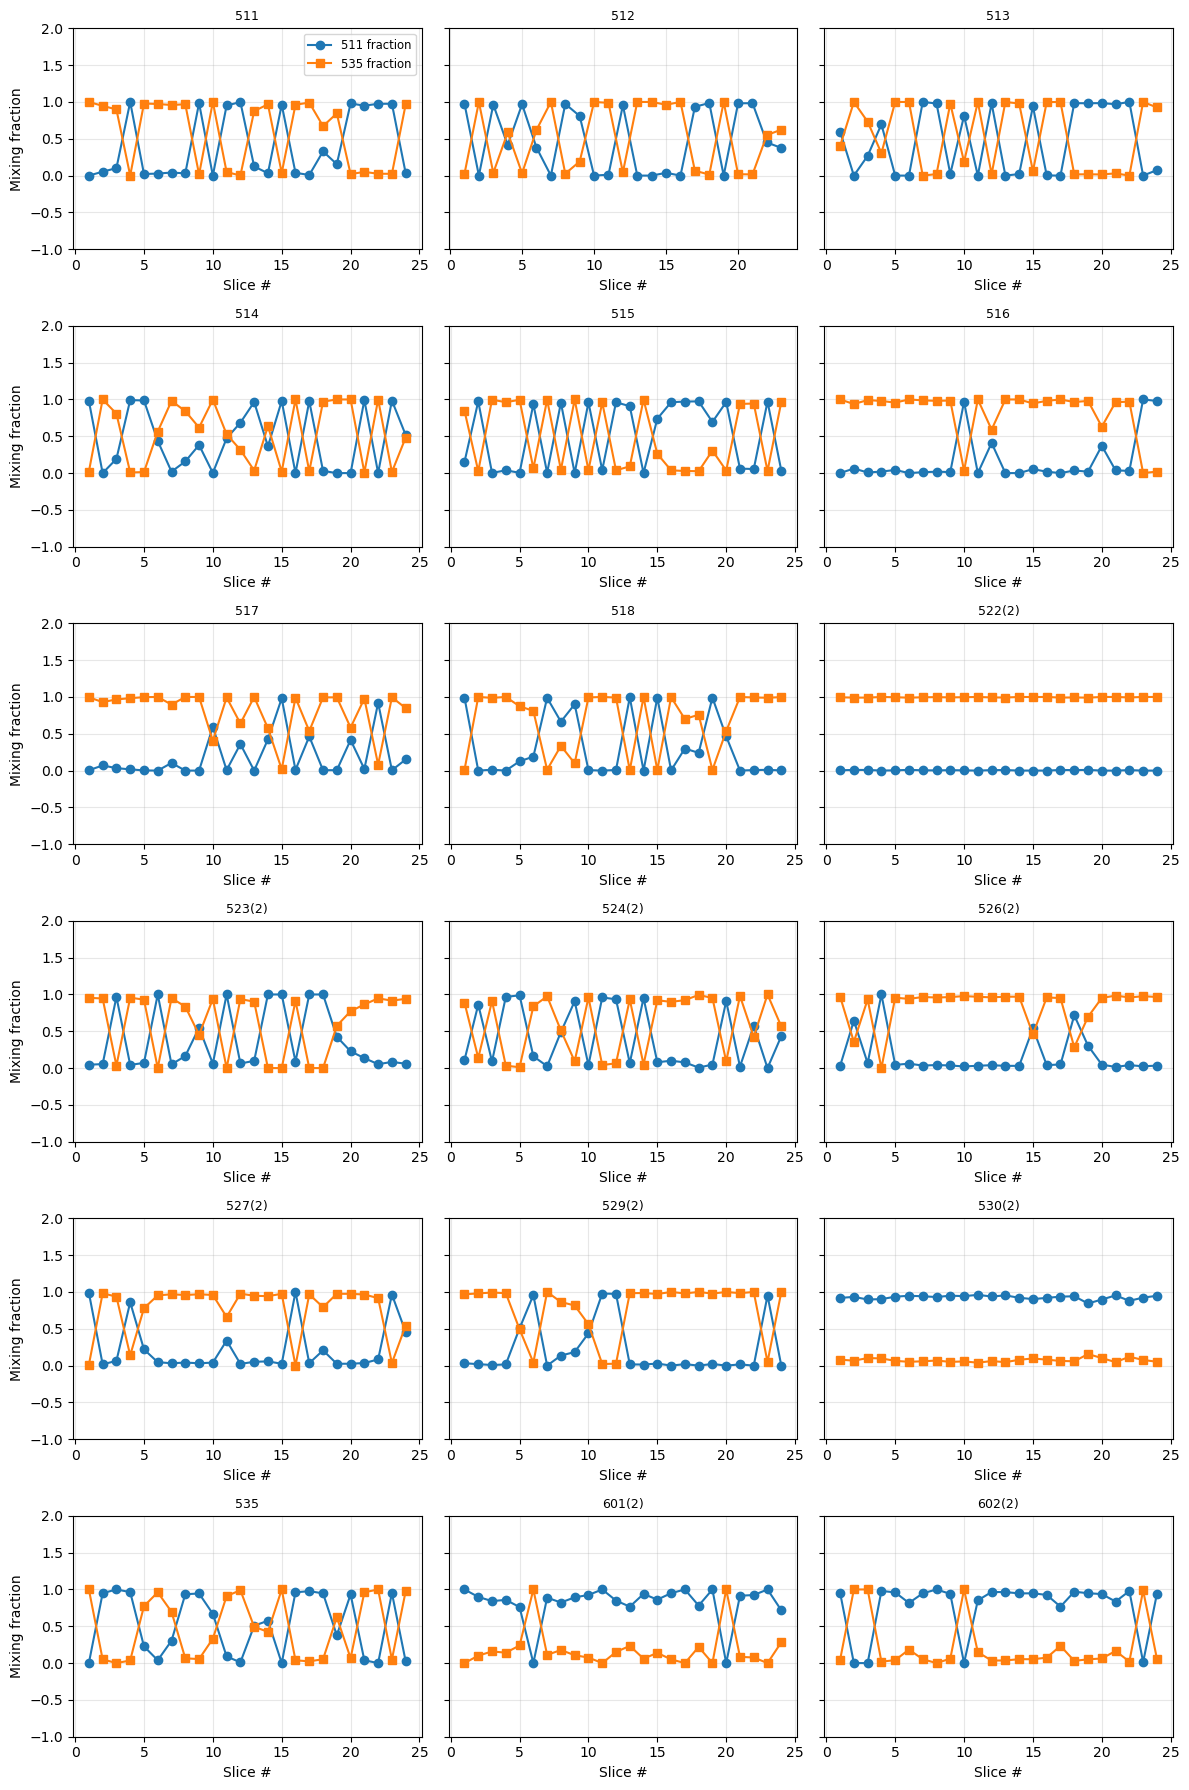

Saved → output/slice_mixing_511_535.csv


In [26]:
# ╭──────────────────────────────────────────────────────────╮
# │  SLICE‑level mixing fractions — all samples / all slices │
# ╰──────────────────────────────────────────────────────────╯
from scipy.optimize import nnls
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1. 6‑exp design matrix, using the fast‑mid‑slow rates we just derived
def design_6exp(t):
    return np.column_stack([
        np.exp(-kA_fast*t), np.exp(-kA_mid*t), np.exp(-kA_slow*t),
        np.exp(-kB_fast*t), np.exp(-kB_mid*t), np.exp(-kB_slow*t)
    ])

slice_mix = {}   # sample → (fracA array, fracB array)

for smp, df in data_dict.items():
    t = df["Time"].to_numpy(float)
    X = design_6exp(t)

    cols = [c for c in df.columns
            if c.startswith(f"Sample_{smp.split('(')[0]}")]

    fracA, fracB = [], []
    for col in cols:
        amps, _ = nnls(X, df[col].to_numpy(float))   # 6 amplitudes
        A1p,A2p,A3p,B1p,B2p,B3p = amps
        totA, totB = A1p+A2p+A3p, B1p+B2p+B3p
        denom = totA + totB
        fracA.append(totA/denom if denom else np.nan)
        fracB.append(totB/denom if denom else np.nan)

    slice_mix[smp] = (np.array(fracA), np.array(fracB))

# 2. Plot — automatic grid (3 columns)
samples = sorted(slice_mix.keys())
ncols, nrows = 3, -(-len(samples)//3)        # ceiling division
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 3*nrows), sharey=True)
axes = axes.ravel()

for idx, (ax, smp) in enumerate(zip(axes, samples)):
    fA, fB = slice_mix[smp]
    x      = np.arange(1, len(fA)+1)

    ax.plot(x, fA, "-o", label=f"{SOURCE_A} fraction")
    ax.plot(x, fB, "-s", label=f"{SOURCE_B} fraction")
    ax.set_title(smp, fontsize=9)
    ax.set_xlabel("Slice #")
    ax.set_ylim(-1, 2)
    ax.grid(alpha=.3)
    if idx % ncols == 0:
        ax.set_ylabel("Mixing fraction")
    if idx == 0:
        ax.legend(fontsize="small", loc="best")

# hide any unused panels
for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 3. Optional: save slice‑level table
records = [(smp, i, fa, fb)
           for smp, (fA, fB) in slice_mix.items()
           for i, (fa, fb) in enumerate(zip(fA, fB), 1)]

df_slices = pd.DataFrame(records,
                         columns=["Sample", "Slice#",
                                  f"Frac_{SOURCE_A}",
                                  f"Frac_{SOURCE_B}"])
csv_name = f"output/slice_mixing_{SOURCE_A}_{SOURCE_B}.csv"
df_slices.to_csv(csv_name, index=False)
print(f"Saved → {csv_name}")


## 读取数据（原始数据，未经过log变换），共18个样品，每个样品有数个测片。以下代码选取了样品601（2）与602（2）作为物源。各使用两个指数函数（分别代表快慢组分）进行拟合

## 此处我首先计算601（2）和602（2）中的快慢组分：

### 1&nbsp;. Mean decade curve  

$$
\overline{I}_X(t)
= \frac{1}{N}\,\sum_{i=1}^{N} I_{X,i}(t)
$$  

Here \(I_{X,i}(t)\) is the raw OSL count rate of slice \(i\) for sample \(X\) at time \(t\).

---

### 2&nbsp;. Two‑component exponential model  

$$
I(t)\;=\;A_{1}\,e^{-k_{1}t} \;+\; A_{2}\,e^{-k_{2}t}
$$  

* \(A_{1},k_{1}\) — amplitude and decay constant of the **fast** component  
* \(A_{2},k_{2}\) — amplitude and decay constant of the **slow** component  

For source 602 an independent set \((B_{1},k_{1}',B_{2},k_{2}')\) is fitted.

---

### 3&nbsp;. Goodness‑of‑fit (\(R^{2}\))  

$$
R^{2}
= 1 -
\frac{\displaystyle\sum_{t}
       \bigl[\,I_{\text{data}}(t) - I_{\text{fit}}(t)\bigr]^{2}}
     {\displaystyle\sum_{t}
       \bigl[\,I_{\text{data}}(t) - \overline{I_{\text{data}}}\,\bigr]^{2}}
$$


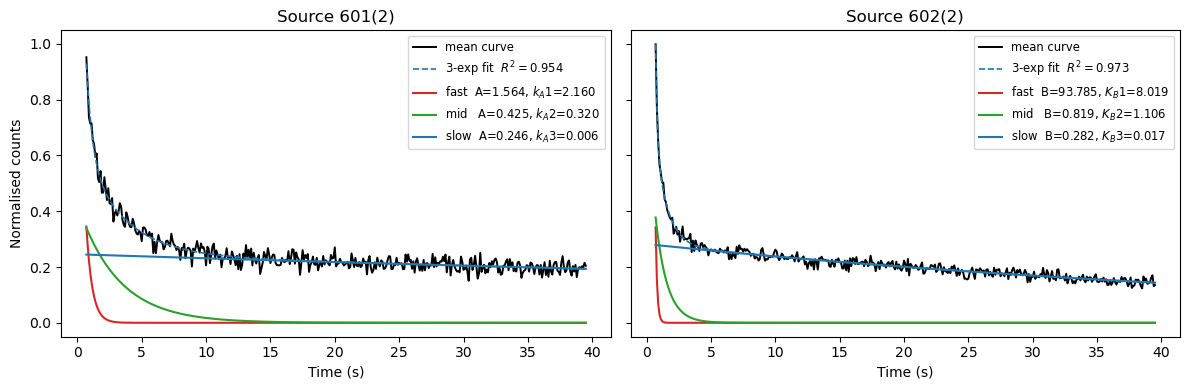

In [9]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from  scipy.optimize import curve_fit

# ─────────────────────────────────────────────────────────────
# Helper utilities
# ─────────────────────────────────────────────────────────────
def load_data(path="output/processed_new_data_ori.pkl"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Pickle not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)

def slice_columns(df, key):
    prefix = f"Sample_{key.split('(')[0]}"
    return [c for c in df.columns if c.startswith(prefix)]

def minmax_scale_df(df, key):
    for col in slice_columns(df, key):
        vmin, vmax = df[col].min(), df[col].max()
        df[col] = (df[col] - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return df

def mean_curve(df, key):
    t   = df["Time"].values.astype(float)
    y   = df[slice_columns(df, key)].mean(axis=1).values.astype(float)
    return t, y

def triple_exp(t, A1, k1, A2, k2, A3, k3):
    return (A1*np.exp(-k1*t) + A2*np.exp(-k2*t) + A3*np.exp(-k3*t))

def r2_score(y_true, y_pred):
    sst = np.sum((y_true - np.mean(y_true))**2)
    sse = np.sum((y_true - y_pred) **2)
    return 1.0 - sse/sst

# ─────────────────────────────────────────────────────────────
# 1. Load data  ➜  min–max scale  ➜  clean outlier slices
# ─────────────────────────────────────────────────────────────
data_dict = load_data()

bad_cols = ["Sample_601(1)","Sample_601(4)","Sample_601(8)",
            "Sample_601(12)","Sample_601(19)","Sample_601(24)"]
if "601(2)" in data_dict:
    data_dict["601(2)"].drop(columns=bad_cols, errors="ignore", inplace=True)

for key in data_dict:
    data_dict[key] = minmax_scale_df(data_dict[key], key)

# ─────────────────────────────────────────────────────────────
# 2. Fit three‑exp models for the two sources
# ─────────────────────────────────────────────────────────────
t601, y601 = mean_curve(data_dict["601(2)"], "601(2)")
p0_601 = [0.8, 0.01, 0.15, 0.1, 0.05, 1.0]           # A1,k1,A2,k2,A3,k3
A1,k1,A2,k2,A3,k3 = curve_fit(triple_exp, t601, y601, p0=p0_601,
                              bounds=(0, np.inf))[0]
fit601 = triple_exp(t601, A1,k1,A2,k2,A3,k3)
r2_601 = r2_score(y601, fit601)

t602, y602 = mean_curve(data_dict["602(2)"], "602(2)")
p0_602 = [A1,k1,A2,k2,A3,k3]
B1,k1b,B2,k2b,B3,k3b = curve_fit(triple_exp, t602, y602, p0=p0_602,
                                 bounds=(0, np.inf))[0]
fit602 = triple_exp(t602, B1,k1b,B2,k2b,B3,k3b)
r2_602 = r2_score(y602, fit602)

# ─────────────────────────────────────────────────────────────
# 3 . Plot mean curve, 3‑exp fit, and the 3 individual terms
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ---------- helper ----------
def sort_amp_rate(A_vec, k_vec):
    """Return amplitudes & rates sorted by descending k (fast→slow)."""
    order = np.argsort(-k_vec)      # largest k first
    return A_vec[order], k_vec[order]

# ========== 601(2) ==========
amps_601 = np.array([A1, A2, A3])
rates_601 = np.array([k1, k2, k3])
A_sorted, k_sorted = sort_amp_rate(amps_601, rates_601)

A_fast, A_mid, A_slow = A_sorted
kA_fast, kA_mid, kA_slow = k_sorted

f_fast = A_fast * np.exp(-kA_fast * t601)
f_mid  = A_mid  * np.exp(-kA_mid  * t601)
f_slow = A_slow * np.exp(-kA_slow * t601)

ax = axes[0]
ax.plot(t601, y601, 'k', lw=1.4, label="mean curve")
ax.plot(t601, fit601, '--', lw=1.2, label=f"3‑exp fit  $R^2={r2_601:.3f}$")
ax.plot(t601, f_fast, color='tab:red',   label=f"fast  A={A_fast:.3f}, $k_A1$={kA_fast:.3f}")
ax.plot(t601, f_mid,  color='tab:green', label=f"mid   A={A_mid :.3f}, $k_A2$={kA_mid :.3f}")
ax.plot(t601, f_slow, color='tab:blue',  label=f"slow  A={A_slow:.3f}, $k_A3$={kA_slow:.3f}")
ax.set_title("Source 601(2)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalised counts")
ax.legend(fontsize="small")

# ========== 602(2) ==========
amps_602 = np.array([B1, B2, B3])
rates_602 = np.array([k1b, k2b, k3b])
B_sorted, kB_sorted = sort_amp_rate(amps_602, rates_602)

B_fast, B_mid, B_slow = B_sorted
KB_fast, KB_mid, KB_slow = kB_sorted

g_fast = B_fast * np.exp(-KB_fast * t602)
g_mid  = B_mid  * np.exp(-KB_mid  * t602)
g_slow = B_slow * np.exp(-KB_slow * t602)

ax = axes[1]
ax.plot(t602, y602, 'k', lw=1.4, label="mean curve")
ax.plot(t602, fit602, '--', lw=1.2, label=f"3‑exp fit  $R^2={r2_602:.3f}$")
ax.plot(t602, g_fast, color='tab:red',   label=f"fast  B={B_fast:.3f}, $K_B1$={KB_fast:.3f}")
ax.plot(t602, g_mid,  color='tab:green', label=f"mid   B={B_mid :.3f}, $K_B2$={KB_mid :.3f}")
ax.plot(t602, g_slow, color='tab:blue',  label=f"slow  B={B_slow:.3f}, $K_B3$={KB_slow:.3f}")
ax.set_title("Source 602(2)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize="small")

plt.tight_layout()
plt.show()


# 接下来我计算了混合比：

假设每个样品中都包含了来自601（2）和602（2）的快慢组分。保持k1, k2, k1b, k2b不变。为每个样品的均值曲线拟合出合适的A1', A2', B1', B2'

根据 A1', A2', B1', B2' 可以计算出混合比为：

Let  

\[
\begin{aligned}
S_{601}&=A_1'+A_2'\\[4pt]
S_{602}&=B_1'+B_2'\\[4pt]
S_{\text{tot}}&=S_{601}+S_{602}
\end{aligned}
\qquad\Longrightarrow\qquad
\begin{aligned}
\text{Fraction from 601(2)} &= \dfrac{S_{601}}{S_\text{tot}}\\[8pt]
\text{Fraction from 602(2)} &= \dfrac{S_{602}}{S_\text{tot}}
\end{aligned}
\tag{5}
\]

---

### Parameter symbols used in the code

| Symbol | Code variable | Description |
|:------:|---------------|-------------|
| \(A_1 ,k_1 ,A_2 ,k_2\) | `A1, k1, A2, k2` | Fit to source 601(2) |
| \(B_1 ,k_1',B_2 ,k_2'\) | `B1, k1b, B2, k2b` | Fit to source 602(2) |
| \(A_1',A_2',B_1',B_2'\) | `amps` from NNLS | Sample‑specific amplitudes in Eq. (4) |
| \(R^2\) | `r2_score` | Fit quality defined in Eq. (3) |


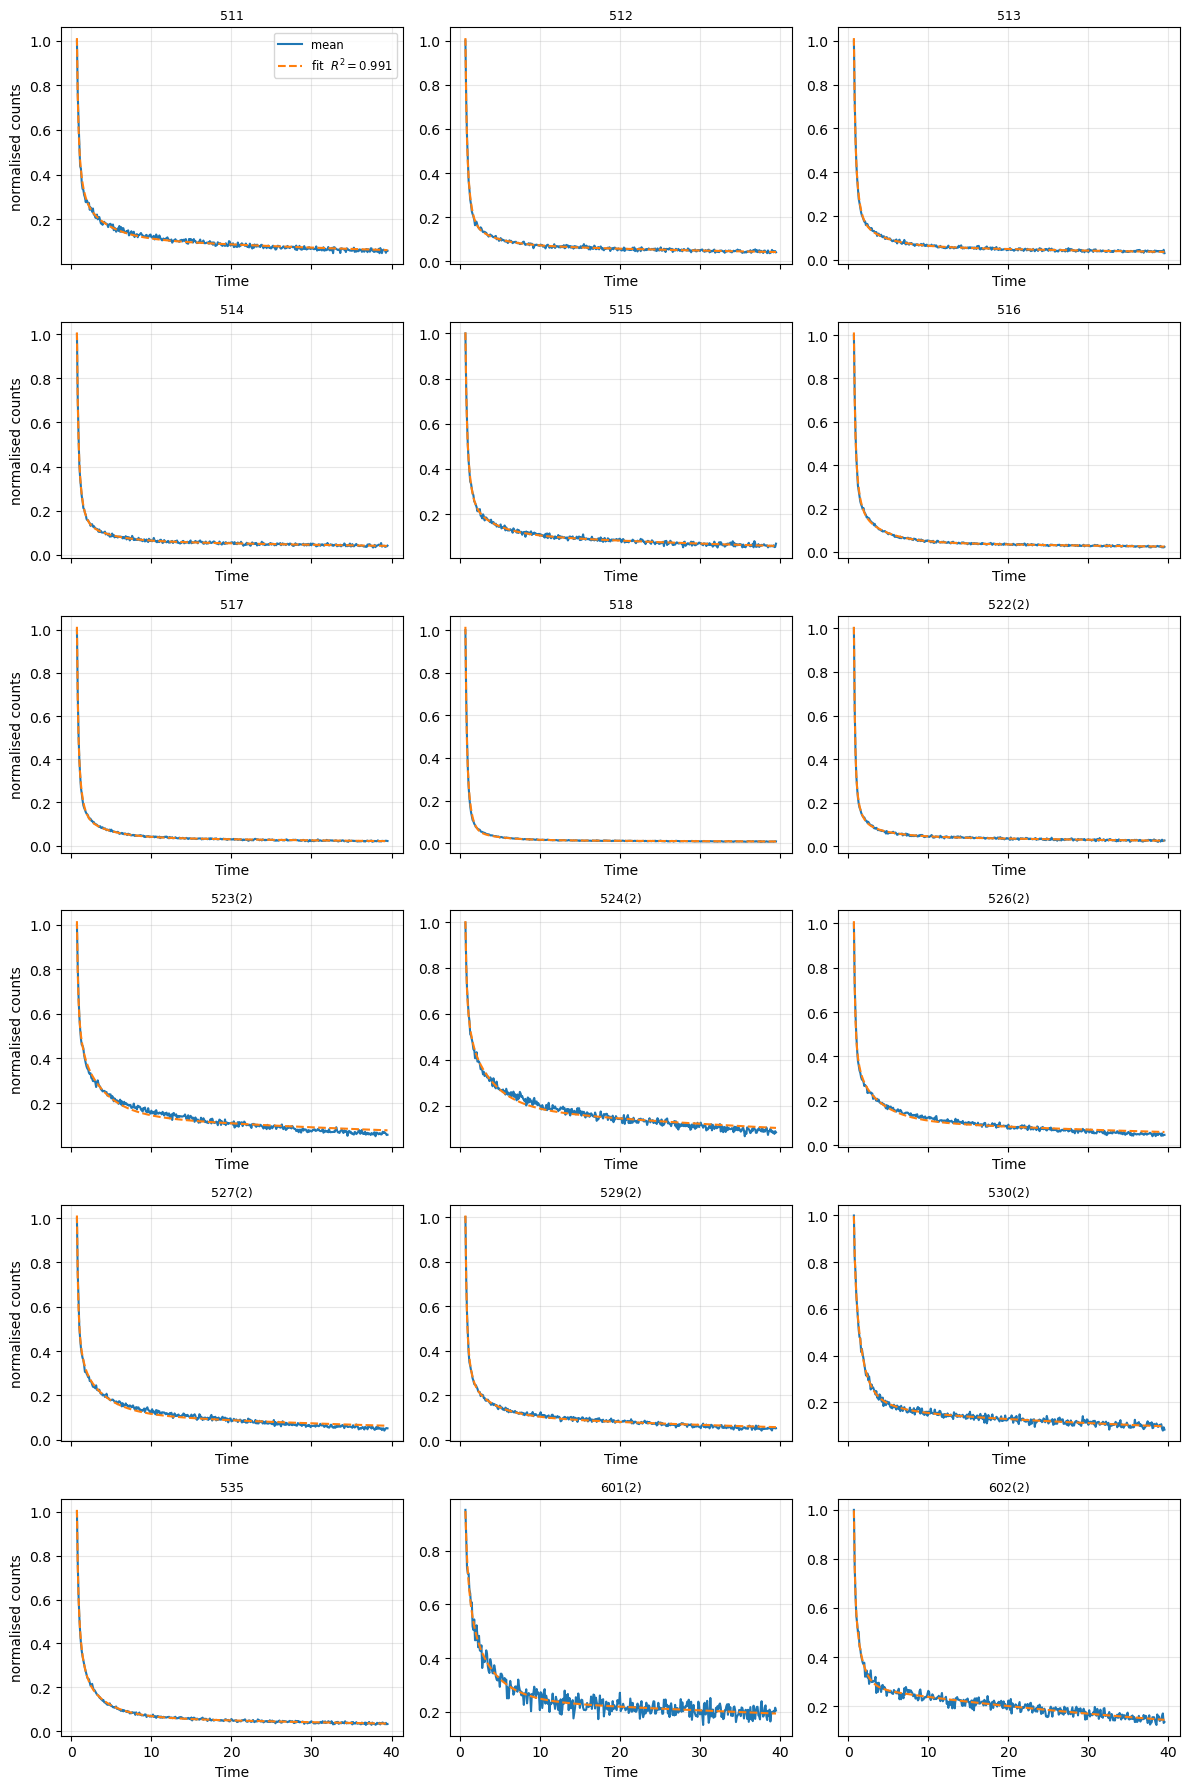


=== Six‑exp amplitudes & total‑signal mixing fractions ===
        A1′(fast601)  A2′(mid601)  A3′(slow601)  B1′(fast602)  B2′(mid602)  B3′(slow602)      R²  Frac601_total  Frac602_total
Sample                                                                                                                        
511           1.5876       0.2578        0.0000       91.1920       0.0000        0.1236  0.9911         0.0198         0.9802
512           2.0690       0.1347        0.0088      101.1193       0.0000        0.0701  0.9955         0.0214         0.9786
513           1.9437       0.1664        0.0058      105.4733       0.0000        0.0604  0.9968         0.0197         0.9803
514           1.9450       0.1301        0.0207      111.8452       0.0000        0.0466  0.9965         0.0184         0.9816
515           1.9364       0.1939        0.0000       84.3544       0.0000        0.1159  0.9946         0.0246         0.9754
516           1.7289       0.2118        0.0000    

,A1′(fast601),A2′(mid601),A3′(slow601),B1′(fast602),B2′(mid602),B3′(slow602),R²,Frac601_total,Frac602_total
Sample,,,,,,,,,
511,1.5876,0.2578,0.0000,91.1920,0.0000,0.1236,0.9911,0.0198,0.9802
512,2.0690,0.1347,0.0088,101.1193,0.0000,0.0701,0.9955,0.0214,0.9786
513,1.9437,0.1664,0.0058,105.4733,0.0000,0.0604,0.9968,0.0197,0.9803
514,1.9450,0.1301,0.0207,111.8452,0.0000,0.0466,0.9965,0.0184,0.9816
515,1.9364,0.1939,0.0000,84.3544,0.0000,0.1159,0.9946,0.0246,0.9754
516,1.7289,0.2118,0.0000,113.5988,0.0000,0.0478,0.9982,0.0168,0.9832
517,1.8172,0.1461,0.0000,124.6819,0.0000,0.0410,0.9984,0.0155,0.9845
518,2.0832,0.0685,0.0000,133.2284,0.0000,0.0154,0.9982,0.0159,0.9841
522(2),1.0535,0.0998,0.0026,164.8204,0.0970,0.0465,0.9980,0.0070,0.9930


In [11]:
# ------------------------------------------------------------
#  STEP 3 – six‑component NNLS fit (fast/mid/slow ordering)
# ------------------------------------------------------------
from scipy.optimize import nnls   # non‑negative LS

# --- 1. sort the source decay constants ---------------------
kA_vec = np.array([k1,  k2,  k3 ])     # 601(2) rates
kB_vec = np.array([k1b, k2b, k3b])     # 602(2) rates

orderA = np.argsort(-kA_vec)           # descending → fast, mid, slow
orderB = np.argsort(-kB_vec)

kA_fast, kA_mid, kA_slow = kA_vec[orderA]
kB_fast, kB_mid, kB_slow = kB_vec[orderB]

def basis_matrix6(t):
    """exp columns in the order fast→mid→slow for each source."""
    return np.column_stack([
        np.exp(-kA_fast * t), np.exp(-kA_mid * t), np.exp(-kA_slow * t),
        np.exp(-kB_fast * t), np.exp(-kB_mid * t), np.exp(-kB_slow * t)
    ])

# --- 2. fit every sample, plot in a 3×? grid ----------------
records = []
samples = sorted(data_dict.keys())
ncols   = 3
nrows   = int(np.ceil(len(samples) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 3*nrows),
                         sharex=True, sharey=False)
axes = axes.ravel()

for idx, sample in enumerate(samples):
    t, y = mean_curve(data_dict[sample], sample)
    X    = basis_matrix6(t)

    amps, _ = nnls(X, y)               # NNLS ⇒ non‑negative amplitudes
    (A1p, A2p, A3p,
     B1p, B2p, B3p) = amps
    y_hat = X @ amps
    r2val = r2_score(y, y_hat)

    # store ---------------------------------------------------
    total_601 = A1p + A2p + A3p
    total_602 = B1p + B2p + B3p
    total_sum = total_601 + total_602
    frac601   = total_601 / total_sum if total_sum else np.nan
    frac602   = total_602 / total_sum if total_sum else np.nan

    records.append([sample, A1p, A2p, A3p, B1p, B2p, B3p,
                    r2val, frac601, frac602])

    # plot ----------------------------------------------------
    ax = axes[idx]
    ax.plot(t, y,        label="mean")
    ax.plot(t, y_hat, '--', label=f"fit  $R^2={r2val:.3f}$")
    ax.set_title(sample, fontsize=9)
    if idx % ncols == 0:
        ax.set_ylabel("normalised counts")
    ax.set_xlabel("Time")
    ax.grid(alpha=.3)
    if idx == 0:
        ax.legend(fontsize="small")

# hide empty panels
for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# --- 3.  coefficient / mixing table -------------------------
cols = ["A1′(fast601)", "A2′(mid601)", "A3′(slow601)",
        "B1′(fast602)", "B2′(mid602)", "B3′(slow602)",
        "R²", "Frac601_total", "Frac602_total"]

df_coef = (pd.DataFrame.from_records(records, columns=["Sample", *cols])
                     .set_index("Sample")
                     .round(4)
                     .sort_index())

print("\n=== Six‑exp amplitudes & total‑signal mixing fractions ===")
print(df_coef.to_string())

df_coef.to_csv("output/six_exp_coefficients_and_mixing.csv")
print("\nSaved → output/six_exp_coefficients_and_mixing.csv")

# pretty display (Jupyter)
try:
    from IPython.display import display
    display(df_coef)
except Exception:
    pass


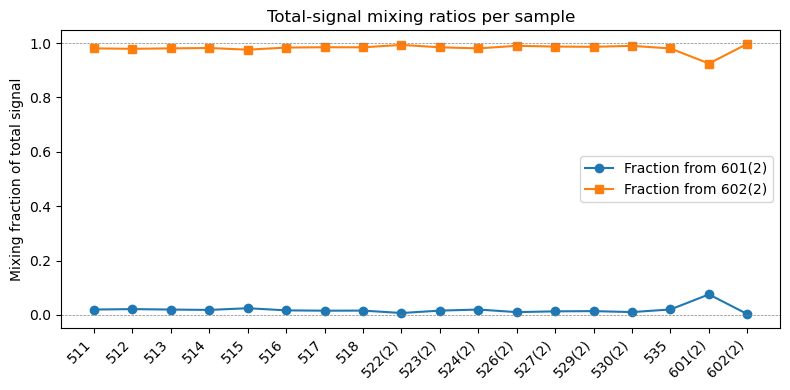

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


df_plot = df_coef.copy()

# Sort samples in alphabetical order for consistent x‑axis
df_plot = df_plot.sort_index()

x = range(len(df_plot))
plt.figure(figsize=(8, 4))
plt.plot(x, df_plot["Frac601_total"], marker="o", label="Fraction from 601(2)")
plt.plot(x, df_plot["Frac602_total"], marker="s", label="Fraction from 602(2)")
# plot horizontal lines at y=0 and 1
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(x, df_plot.index, rotation=45, ha="right")
plt.ylabel("Mixing fraction of total signal")
plt.title("Total‑signal mixing ratios per sample")
plt.legend()
plt.tight_layout()
plt.show()


## 结论：518， 522（2）和524（2）或不属于601（2）与602（2）的体系。

# 以下为每个测片的混合比

Decay rates used: (0.6237059191891695, 0.007068725059993577, 1.7201928528978607, 0.007172665191298096)


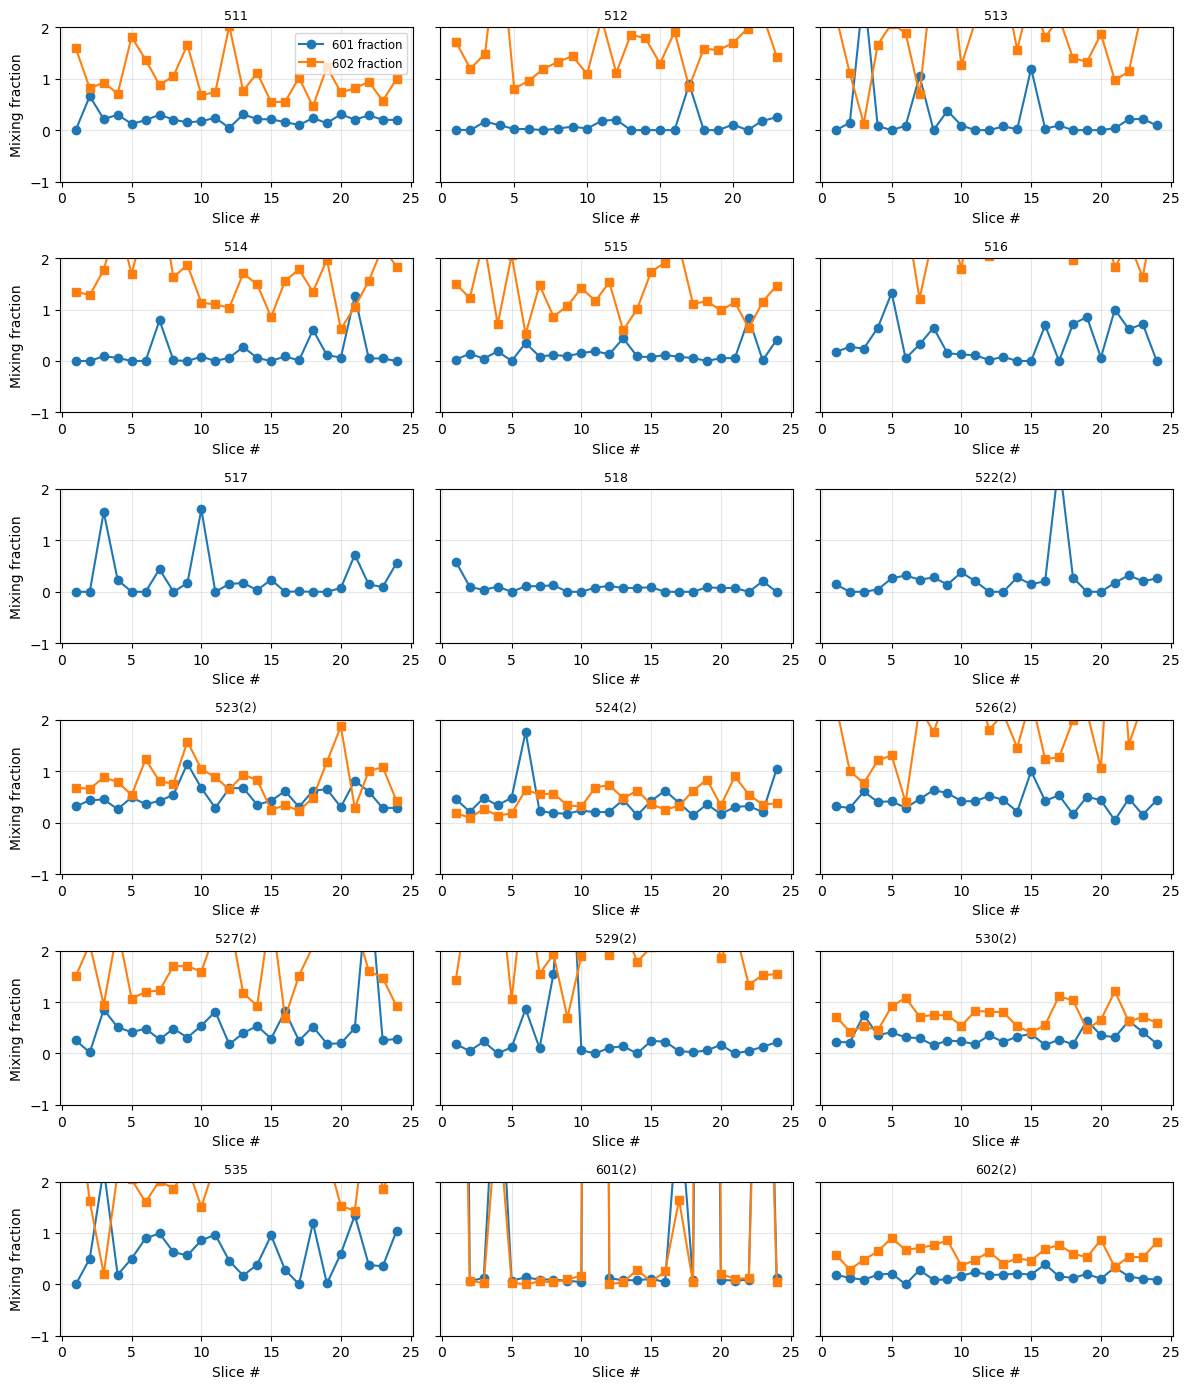

In [26]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls   # non‑negative least squares

# ------------------------------------------------------------------
# 1. Load the **raw‑count** pickle and reuse the fitted decay rates
#    (k1, k2 from 601; k1b, k2b from 602) already in memory.
# ------------------------------------------------------------------
data = load_data("output/processed_new_data_ori.pkl")   # uses your helper

# make sure k1, k2, k1b, k2b are defined from the source fits above
rates = (k1, k2, k1b, k2b)
print("Decay rates used:", rates)

# ------------------------------------------------------------------
# 2. Helper: four‑column design matrix with the fixed rates
# ------------------------------------------------------------------
def design_4exp(t, k1, k2, k1b, k2b):
    return np.column_stack([
        np.exp(-k1  * t),      # fast‑601   (A1′)
        np.exp(-k2  * t),      # slow‑601   (A2′)
        np.exp(-k1b * t),      # fast‑602   (B1′)
        np.exp(-k2b * t),      # slow‑602   (B2′)
    ])

# ------------------------------------------------------------------
# 3. For every sample & every slice: solve NNLS amplitudes,
#    then compute total‑signal fractions for 601 and 602.
# ------------------------------------------------------------------
mix_dict = {}   # sample -> list of (frac601, frac602) per slice

for key, df in data.items():
    t  = df["Time"].to_numpy(dtype=float)
    X  = design_4exp(t, *rates)
    
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [col for col in df.columns if col.startswith(prefix)]
    
    fracs_601, fracs_602 = [], []
    for col in slice_cols:
        y = df[col].to_numpy(dtype=float)
        # non‑negative least squares for A1′,A2′,B1′,B2′
        amps, _ = nnls(X, y)
        a1p, a2p, b1p, b2p = amps
        total601 = a1p + a2p
        total602 = b1p + b2p
        # denom    = total601 + total602
        denom    = A1 + A2 + B1 + B2
        fracs_601.append(total601 / denom if denom else np.nan)
        fracs_602.append(total602 / denom if denom else np.nan)
    
    mix_dict[key] = (np.array(fracs_601), np.array(fracs_602))


samples_sorted = sorted(mix_dict.keys())
n_rows, n_cols = 6, 3                        # 6×3 = 18 panels
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(12, 14), sharey=True)
axes = axes.ravel()

for idx, (ax, sample) in enumerate(zip(axes, samples_sorted)):
    frac601, frac602 = mix_dict[sample]
    slices = np.arange(1, len(frac601) + 1)

    ax.plot(slices, frac601, "-o", label="601 fraction")
    ax.plot(slices, frac602, "-s", label="602 fraction")
    ax.set_title(sample, fontsize=9)
    ax.set_xlabel("Slice #")
    ax.set_ylim(-1, 2)
    ax.grid(True, alpha=0.3)

    # first column → add common y‑label
    if idx % n_cols == 0:
        ax.set_ylabel("Mixing fraction")

    # put the legend only on the very first subplot to avoid clutter
    if idx == 0:
        ax.legend(fontsize="small", loc="upper right")

# Hide any leftover empty axes (if <18 samples)
for ax in axes[len(samples_sorted):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
